# Paper revision notebook — RT emulator

Single consolidated notebook backing the ApJ revision response. Replaces `00_testing.ipynb`, `01_tuning_analysis.ipynb`, `export.py`, `errors.py`, `plot_example.py`, `training_progression.py`, and `benchmark_inference.py`.

**Outputs**
- `figs/reviewer_fig_*.png` — 9 figures for the reviewer response and updated paper.
- `tuning_all_trials.csv`, `tuning_top10_summary.csv` — sweep evidence tables.
- `per_channel_test_errors.json` — held-out test-set error stats per flux channel.
- `numbers_for_response.json` — every quantity referenced as `[PLACEHOLDER]` in `Paper_Work/reviewer_response.txt`.
- `../models/transformer_main/stand_alone_model.pt2` — physical-space exported model.
- `../models/transformer_main/inference_benchmark_{cuda|mps|cpu}.json` — latency benchmarks.

Run top-to-bottom. The final cell prints `READY FOR RESPONSE` if all artifacts were produced.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import math
import os
import platform
import sys
import time
import statistics
import csv
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, ScalarFormatter

import torch
from torch import Tensor

# ---- Paths
THIS_DIR = Path.cwd()
PROJECT_ROOT = next(p for p in [THIS_DIR, *THIS_DIR.parents] if (p / "src").is_dir())
SRC_DIR = PROJECT_ROOT / "src"
TESTING_DIR = PROJECT_ROOT / "testing"
FIGS_DIR = TESTING_DIR / "figs"
FIGS_DIR.mkdir(exist_ok=True)
MODEL_DIR = PROJECT_ROOT / "models" / "transformer_main"
TUNE_DIR = PROJECT_ROOT / "models" / "tune_rt_tune_20260512_181651"
PROC_ROOT = PROJECT_ROOT / "data" / "processed"
PROC_TEST = PROC_ROOT / "test"
NORM_META_PATH = PROC_ROOT / "normalization_metadata.json"
STYLE_PATH = TESTING_DIR / "science.mplstyle"
STANDALONE_PT2 = MODEL_DIR / "stand_alone_model.pt2"
MODEL_PRESENT = MODEL_DIR.is_dir() and (MODEL_DIR / "train_config.json").is_file()

if STYLE_PATH.is_file():
    plt.style.use(str(STYLE_PATH))


def fix_log_ticks(ax, axis="y"):
    """Force visible major + minor log ticks even when data spans < 1 decade.

    Default LogLocator only places ticks at decade boundaries (1e-3, 1e-2, ...).
    When val_loss is ~2e-3 to ~3e-3 (sub-decade), that yields 0 visible ticks.
    Use subs=[1..9] to also tick at 2e-3, 3e-3, ..., 9e-3.
    """
    axes = (ax.yaxis,) if axis == "y" else (ax.xaxis,) if axis == "x" else (ax.xaxis, ax.yaxis)
    for a in axes:
        a.set_major_locator(LogLocator(base=10.0, subs=(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0), numticks=24))
        a.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=200))
        a.set_major_formatter(LogFormatterSciNotation(base=10.0, labelOnlyBase=False, minor_thresholds=(2, 0.4)))


# Make src importable for create_prediction_model / load_config / DataNormalizer / dataset helpers.
for p in (str(PROJECT_ROOT), str(SRC_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)


# ---- Device detection (CUDA > MPS > CPU)
def detect_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE_RUN = detect_device()
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"MODEL_DIR    = {MODEL_DIR}")
print(f"TUNE_DIR     = {TUNE_DIR}")
print(f"FIGS_DIR     = {FIGS_DIR}")
print(f"DEVICE_RUN   = {DEVICE_RUN}")
print(f"MODEL_PRESENT= {MODEL_PRESENT}  (set False until `sbatch train.sh` populates MODEL_DIR)")
print(f"torch        = {torch.__version__}")


# Aggressive grid + minor-tick suppression (user request: GET RID OF GRIDS).
plt.rcParams["axes.grid"] = False
plt.rcParams["xtick.minor.visible"] = False
plt.rcParams["ytick.minor.visible"] = False


PROJECT_ROOT = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator
MODEL_DIR    = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/models/transformer_main
TUNE_DIR     = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/models/tune_rt_tune_20260512_181651
FIGS_DIR     = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs
DEVICE_RUN   = mps
MODEL_PRESENT= True  (set False until `sbatch train.sh` populates MODEL_DIR)
torch        = 2.8.0


## 2. Load `transformer_main` config + metadata

Source of truth for `best_epoch`, `test_loss`, `num_parameters`, training wall-clock, and the architecture knobs that go into `tab:params` in `ms.tex`.

In [2]:
from utils import load_config

if MODEL_PRESENT:
    train_config = load_config(MODEL_DIR / "train_config.json")
    with (MODEL_DIR / "test_metrics.json").open("r") as f:
        test_metrics = json.load(f)
    with (MODEL_DIR / "training_metadata.json").open("r") as f:
        training_metadata = json.load(f)
    training_log = pd.read_csv(MODEL_DIR / "training_log.csv")

    best_epoch = int(test_metrics["best_epoch"])
    test_loss_t = float(test_metrics["test_loss"])
    num_parameters_t = int(training_metadata["num_parameters"])
    epochs_completed = int(len(training_log))
    train_seconds_total = float(training_log["time_s"].sum())
    train_hours_total = train_seconds_total / 3600.0

    best_row = training_log.loc[training_log["epoch"] == best_epoch].iloc[0]
    val_at_best = float(best_row["val_loss"])

    # Patience and min_delta come straight from the saved config.
    training_hp = train_config["training_hyperparameters"]
    patience = int(training_hp["early_stopping_patience"])
    min_delta = float(training_hp["min_delta"])
    weight_decay = float(training_hp["weight_decay"])
    ema_decay = float(training_hp["ema_decay"])
    learning_rate_initial = float(training_hp["learning_rate"])
    learning_rate_min = float(training_hp["min_lr"])
    batch_size = int(training_hp["batch_size"])
    gradient_clip = float(training_hp["gradient_clip_val"])
    warmup_epochs = int(training_hp["warmup_epochs"])

    mh = train_config["model_hyperparameters"]
    d_model = int(mh["d_model"])
    nhead = int(mh["transformer"]["nhead"])
    num_layers_t = int(mh["transformer"]["num_layers"])
    dim_feedforward = int(mh["transformer"]["dim_feedforward"])
    dropout_t = float(mh["dropout"])
    attention_dropout_t = float(mh["transformer"]["attention_dropout"])
    film_clamp_t = float(mh["film_clamp"])

    raw_h5_filenames = train_config["data_paths_config"]["hdf5_dataset_filename"]

    print(f"best_epoch        = {best_epoch}")
    print(f"test_loss         = {test_loss_t:.6e}")
    print(f"num_parameters    = {num_parameters_t:,}")
    print(f"epochs_completed  = {epochs_completed}  (early stopping patience={patience}, min_delta={min_delta:g})")
    print(f"train_hours_total = {train_hours_total:.2f} h  ({train_seconds_total/epochs_completed:.1f} s/epoch avg)")
    print(f"val_at_best       = {val_at_best:.6e}")
    print(f"d_model           = {d_model}, nhead={nhead}, layers={num_layers_t}, ffn={dim_feedforward}")
    print(f"weight_decay      = {weight_decay}, ema_decay={ema_decay}")
    print(f"raw HDF5 source   = {raw_h5_filenames}")
else:
    # Sweep-only mode: load the base config so cells that only need data_specification /
    # normalization (e.g. PT-profile figure) still work without a trained model.
    train_config = load_config(PROJECT_ROOT / "config" / "transformer_main.jsonc")
    print("Skipped trained-model section: transformer_main/ not yet trained.")
    print(f"Loaded base config from config/transformer_main.jsonc for sweep-only mode.")
    print("Run `sbatch Problemulator/supercomputer_cmds/train.sh` from the repo root, then re-execute this notebook for trained-model artifacts.")


# Imports needed by the SAFE-paper-replication cells below.
from dataset import create_collate_fn, create_dataset
from torch.utils.data import DataLoader
from normalizer import DataNormalizer
norm_meta = json.load(open(NORM_META_PATH, "r"))
padding_value = float(train_config["data_specification"]["padding_value"])
padding_epsilon = float(train_config["normalization"]["padding_comparison_epsilon"])
h5_files = train_config["data_paths_config"]["hdf5_dataset_filename"]
if isinstance(h5_files, str):
    h5_files = [h5_files]


def denormalize_channel(values, var_name, meta):
    method = meta["normalization_methods"][var_name]
    stats = meta["per_key_stats"][var_name]
    if method != "bool" and stats:
        return DataNormalizer.denormalize_tensor(values.to(torch.float32), method, stats)
    return values


def denormalize_batch(config, meta, inputs_norm, masks, targets_norm, target_masks):
    ds = config["data_specification"]
    in_v, glob_v, tgt_v = ds["input_variables"], ds["global_variables"], ds["target_variables"]
    pad = float(ds["padding_value"])
    seq_norm = inputs_norm["sequence"].to(dtype=torch.float32)
    seq_mask = masks["sequence"].bool()
    seq_phys = torch.empty_like(seq_norm)
    for j, n in enumerate(in_v):
        seq_phys[..., j] = denormalize_channel(seq_norm[..., j], n, meta).to(torch.float32)
    seq_phys[seq_mask] = pad
    glob_phys = None
    if glob_v and "global_features" in inputs_norm:
        gn = inputs_norm["global_features"].to(torch.float32)
        glob_phys = torch.empty_like(gn)
        for j, n in enumerate(glob_v):
            glob_phys[..., j] = denormalize_channel(gn[..., j], n, meta).to(torch.float32)
    tgt_phys = torch.empty_like(targets_norm.to(torch.float32))
    tgt_mask = target_masks.bool()
    for j, n in enumerate(tgt_v):
        tgt_phys[..., j] = denormalize_channel(targets_norm[..., j].to(torch.float32), n, meta).to(torch.float32)
    tgt_phys[tgt_mask] = pad
    return seq_phys, glob_phys, tgt_phys, tgt_mask


best_epoch        = 57
test_loss         = 2.098327e-03
num_parameters    = 26,408,194
epochs_completed  = 60  (early stopping patience=12, min_delta=1e-05)
train_hours_total = 2.41 h  (144.5 s/epoch avg)
val_at_best       = 2.098327e-03
d_model           = 512, nhead=4, layers=5, ffn=4096
weight_decay      = 0.05, ema_decay=0.999
raw HDF5 source   = ['picaso_results_5M.h5']


## 2.5 Figure: training-set pressure-temperature coverage (Figure 2 in paper)

Reads a sample of test-set profiles from `data/processed/test/` and the raw HDF5 source, denormalizes pressure and temperature, and plots them in (T, log P) space colored by orbital distance. Saved as `figs/reviewer_fig_pt.png`. The original `pt.png` in `Paper_Work/NN_Paper/` is intentionally left untouched -- this is the reproducible companion plot built from the same dataset.

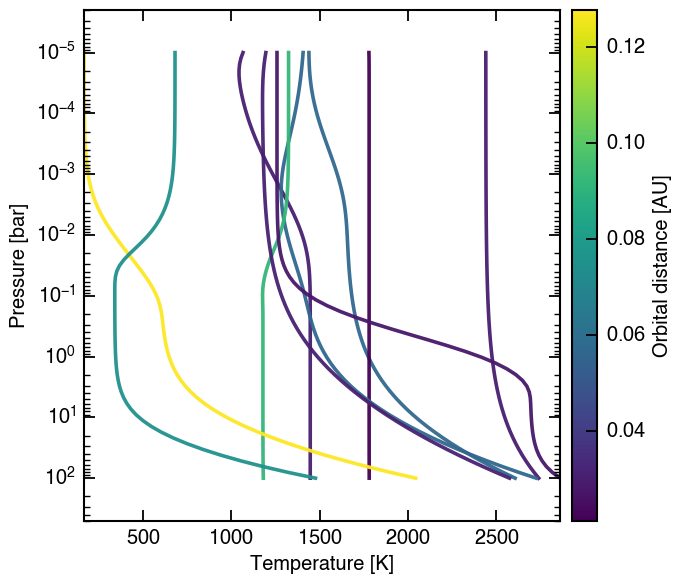

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_pt.png (sampled 10 profiles, seed=42).


In [3]:
# PT profile coverage figure -- regenerable from the processed test split.
# Uses the same denormalization pattern as section 10 (profiles).
from dataset import create_collate_fn, create_dataset
from torch.utils.data import DataLoader
from normalizer import DataNormalizer

with NORM_META_PATH.open("r") as f:
    norm_meta_pt = json.load(f)

with (PROC_TEST / "metadata.json").open("r") as f:
    pt_total_samples = int(json.load(f)["total_samples"])

PT_N_PROFILES = 10
PT_SEED = 42
rng_pt = np.random.default_rng(PT_SEED)
pt_indices = sorted(rng_pt.choice(pt_total_samples, size=min(PT_N_PROFILES, pt_total_samples), replace=False).tolist())

ds_pt = create_dataset(PROC_TEST, train_config, indices=pt_indices)
padding_value_pt = float(train_config["data_specification"]["padding_value"])
padding_epsilon_pt = float(train_config["normalization"]["padding_comparison_epsilon"])
loader_pt = DataLoader(
    ds_pt, batch_size=PT_N_PROFILES, shuffle=False,
    collate_fn=create_collate_fn(padding_value_pt, padding_epsilon_pt), drop_last=False,
)

input_vars_pt = train_config["data_specification"]["input_variables"]
global_vars_pt = train_config["data_specification"]["global_variables"]
pres_idx = input_vars_pt.index("pressure_bar")
temp_idx = input_vars_pt.index("temperature_k")
orb_idx = global_vars_pt.index("orbital_distance_m") if "orbital_distance_m" in global_vars_pt else None

def _denorm_one(values, var_name):
    method = norm_meta_pt["normalization_methods"][var_name]
    stats = norm_meta_pt["per_key_stats"][var_name]
    return DataNormalizer.denormalize_tensor(values.to(torch.float32), method, stats)

inputs_norm_pt, masks_pt, _, _ = next(iter(loader_pt))
seq_norm_pt = inputs_norm_pt["sequence"]                                  # [B, L, F]
seq_mask_pt = masks_pt["sequence"]                                         # True = padding
B_pt, L_pt, _ = seq_norm_pt.shape
pres_phys = _denorm_one(seq_norm_pt[..., pres_idx], "pressure_bar").cpu().numpy()       # bar
temp_phys = _denorm_one(seq_norm_pt[..., temp_idx], "temperature_k").cpu().numpy()      # K
valid_pt = (~seq_mask_pt).cpu().numpy()                                                  # True = non-padding

if orb_idx is not None and "global_features" in inputs_norm_pt:
    glob_norm_pt = inputs_norm_pt["global_features"][..., orb_idx]
    glob_phys_pt = _denorm_one(glob_norm_pt, "orbital_distance_m").cpu().numpy()         # meters
    M_PER_AU = 1.495978707e11
    glob_au = glob_phys_pt / M_PER_AU
    norm_cmap = plt.Normalize(vmin=float(np.min(glob_au)), vmax=float(np.max(glob_au)))
    cmap = plt.get_cmap("viridis")
else:
    glob_au = None

fig_pt, ax_pt = plt.subplots(figsize=(7.0, 6.0))
(ax_pt if isinstance(ax_pt, np.ndarray) else np.array([ax_pt])).ravel()  # no-op shim
for _ax in (plt.gcf().axes):
    _ax.grid(False, which="both")
for b in range(B_pt):
    v = valid_pt[b]
    if not v.any():
        continue
    p_b = pres_phys[b, v]
    t_b = temp_phys[b, v]
    if glob_au is not None:
        ax_pt.plot(t_b, p_b, color=cmap(norm_cmap(glob_au[b])), linewidth=2.6, alpha=0.95)
    else:
        ax_pt.plot(t_b, p_b, color="black", linewidth=2.6, alpha=0.95)

ax_pt.set_yscale("log")
ax_pt.invert_yaxis()
ax_pt.set_xlabel("Temperature [K]")
ax_pt.set_ylabel("Pressure [bar]")

if glob_au is not None:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_cmap)
    sm.set_array([])
    cbar = fig_pt.colorbar(sm, ax=ax_pt, pad=0.02)
    cbar.set_label("Orbital distance [AU]")

fig_pt.tight_layout()
pt_out = FIGS_DIR / "reviewer_fig_pt.png"
fig_pt.savefig(pt_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Wrote {pt_out} (sampled {B_pt} profiles, seed={PT_SEED}).")

## 3. Load the 64-trial Optuna sweep

Read `leaderboard.json` and `all_trials.json`, build a per-trial DataFrame, and persist `tuning_all_trials.csv` + `tuning_top10_summary.csv` to `testing/`.

In [4]:
with (TUNE_DIR / "leaderboard.json").open("r") as f:
    leaderboard = json.load(f)

raw_all_trials = json.load((TUNE_DIR / "all_trials.json").open("r"))
all_trials = raw_all_trials["trials"] if isinstance(raw_all_trials, dict) else raw_all_trials


def trial_to_row(trial: Dict[str, Any]) -> Dict[str, Any]:
    row = {
        "number": trial["number"],
        "state": trial["state"],
        "val_loss": trial.get("value"),
        "duration_s": trial.get("duration_s"),
        "datetime_start": trial.get("datetime_start"),
        "datetime_complete": trial.get("datetime_complete"),
    }
    row.update(trial.get("user_attrs", {}))
    row.update(trial.get("params", {}))
    return row


trials_df = pd.DataFrame([trial_to_row(t) for t in all_trials])
if "ffn_mult" in trials_df.columns:
    trials_df["dim_feedforward"] = (trials_df["d_model"] * trials_df["ffn_mult"]).where(
        trials_df["model_type"] == "transformer"
    )
trials_df["num_parameters_M"] = trials_df["num_parameters"] / 1e6
trials_df = trials_df.sort_values(["val_loss", "number"]).reset_index(drop=True)

complete_df = trials_df[trials_df["state"] == "COMPLETE"].copy()

t_rows = complete_df[complete_df["model_type"] == "transformer"]
l_rows = complete_df[complete_df["model_type"] == "lstm"]

if t_rows.empty:
    raise RuntimeError("No completed transformer trials in TUNE_DIR; nothing to plot.")
best_t = t_rows.iloc[0]
best_t_trial = int(best_t["number"])
best_t_val = float(best_t["val_loss"])
best_t_params = int(best_t["num_parameters"])

if l_rows.empty:
    best_l = None
    best_l_trial = None
    best_l_val = float("nan")
    best_l_params = 0
else:
    best_l = l_rows.iloc[0]
    best_l_trial = int(best_l["number"])
    best_l_val = float(best_l["val_loss"])
    best_l_params = int(best_l["num_parameters"])

# Save full trials and top 10 to CSV.
# (skipping disk write of tuning_all_trials.csv per user request)

TOP10_COLS = [
    "number", "model_type", "val_loss", "num_parameters",
    "d_model", "num_layers_transformer", "num_layers_lstm",
    "nhead", "ffn_mult", "dropout", "attention_dropout",
    "film_clamp", "output_head_divisor", "output_head_dropout_factor",
    "duration_s",
]
top10_cols_avail = [c for c in TOP10_COLS if c in trials_df.columns]
top10 = trials_df.head(10)[top10_cols_avail].copy()
# (skipping disk write of tuning_top10_summary.csv per user request)

n_total = int(leaderboard.get("n_trials_total", len(trials_df)))
n_complete = int(leaderboard.get("n_trials_complete", len(complete_df)))
n_pruned = int(leaderboard.get("n_trials_pruned", (trials_df["state"] == "PRUNED").sum()))

print(f"Sweep: {n_total} trials ({n_complete} complete, {n_pruned} pruned).")
print(f"  Best transformer: trial {best_t_trial}  val_loss={best_t_val:.6e}  params={best_t_params:,}")
if best_l is not None:
    ratio_t_vs_l = best_l_val / best_t_val
    print(f"  Best LSTM:        trial {best_l_trial}  val_loss={best_l_val:.6e}  params={best_l_params:,}")
    print(f"  Transformer-vs-LSTM ratio (val_loss): {ratio_t_vs_l:.3f}x lower")
else:
    print("  Best LSTM:        (no completed LSTM trials in this sweep)")
print(f"  Wrote {TESTING_DIR / 'tuning_top10_summary.csv'}")


Sweep: 32 trials (31 complete, 1 pruned).
  Best transformer: trial 20  val_loss=2.098327e-03  params=26,408,194
  Best LSTM:        trial 2  val_loss=2.162529e-03  params=9,730,050
  Transformer-vs-LSTM ratio (val_loss): 1.031x lower
  Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/tuning_top10_summary.csv


## 4. Figure: Pareto plot — validation loss vs trainable parameters (R1.1, R1.2, R1.6)

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_pareto.png


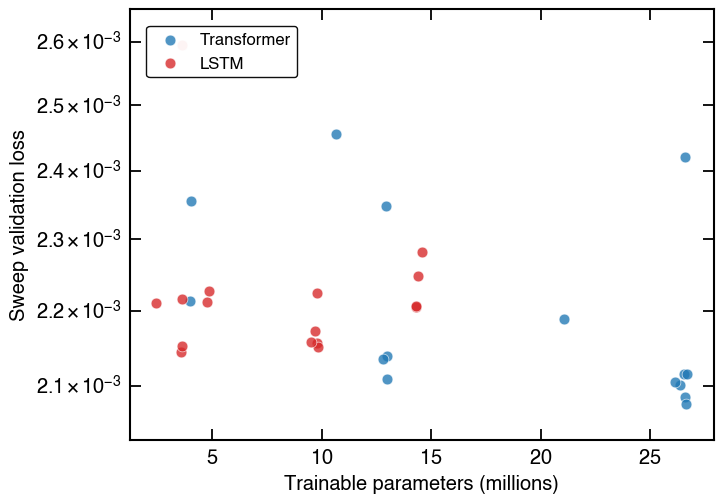

In [5]:
ARCH_STYLE = {
    "transformer": {"label": "Transformer", "color": "#1f77b4"},
    "lstm":        {"label": "LSTM",        "color": "#d62728"},
}

_jitter_rng = np.random.default_rng(42)
def _jitter(arr, scale=0.012):
    return arr * (1.0 + _jitter_rng.uniform(-scale, scale, size=len(arr)))

fig, ax = plt.subplots(figsize=(7.4, 5.2))
(ax if isinstance(ax, np.ndarray) else np.array([ax])).ravel()  # no-op shim
for _ax in (plt.gcf().axes):
    _ax.grid(False, which="both")
for fam, style in ARCH_STYLE.items():
    sub = trials_df[trials_df["model_type"] == fam].dropna(subset=["val_loss", "num_parameters_M"])
    if sub.empty:
        continue
    ax.scatter(
        _jitter(sub["num_parameters_M"].to_numpy()),
        _jitter(sub["val_loss"].to_numpy()),
        marker="o",
        color=style["color"],
        edgecolors="white",
        linewidths=0.5,
        alpha=0.78,
        s=60,
        label=style["label"],
        zorder=3,
    )

ax.legend(loc="upper left", frameon=True, framealpha=0.94)
ax.set_xlabel("Trainable parameters (millions)")
ax.set_ylabel("Sweep validation loss")
ax.set_yscale("log")
fix_log_ticks(ax, axis="y")
ax.grid(False)

fig.tight_layout()
out = FIGS_DIR / "reviewer_fig_pareto.png"
fig.savefig(out, dpi=220, bbox_inches="tight")
print(f"Wrote {out}")
plt.show()


## 7. Figure: `transformer_main` training curves (R1.3, R1.5)

Train + val loss vs epoch (log-y) with `best_epoch=112` axvline; right panel is the LR schedule. The 5-epoch rolling-median overlay makes the noise-floor explicit. **Replaces paper `training.png`.**

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_training_curves.png


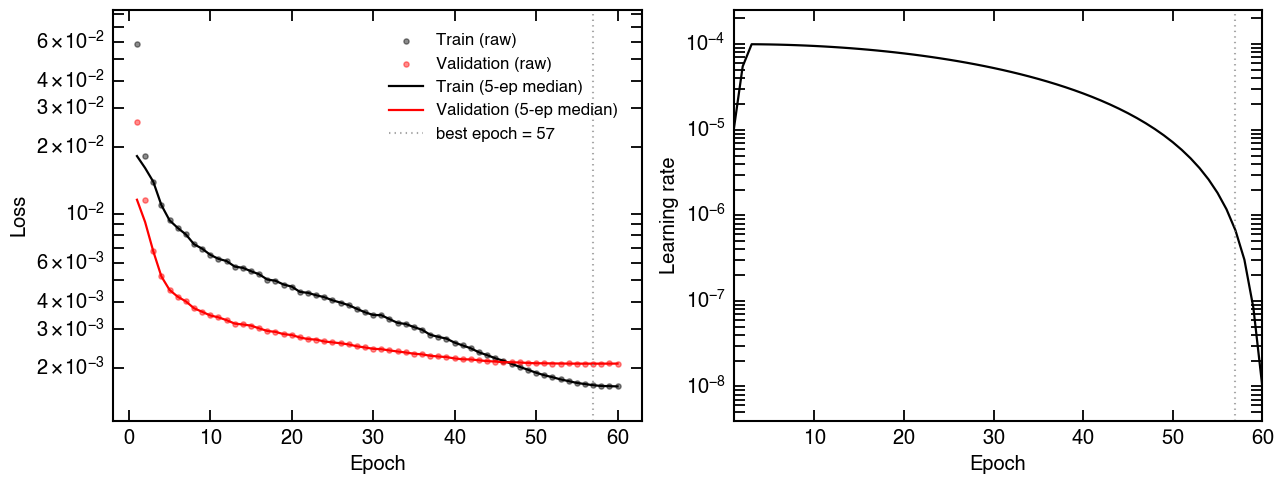


best_epoch                = 57
val_loss at best_epoch    = 2.098327e-03
val_loss at final epoch   = 2.101524e-03  (epoch 60)
train_loss at final epoch = 1.655587e-03
train/val gap at final    = 0.788


In [6]:
if MODEL_PRESENT:
    log = training_log.copy()
    log = log.dropna(subset=["epoch", "train_loss", "val_loss", "lr"]).sort_values("epoch")

    # rolling-median smoothing
    log["val_smooth"] = log["val_loss"].rolling(5, min_periods=1, center=True).median()
    log["train_smooth"] = log["train_loss"].rolling(5, min_periods=1, center=True).median()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.scatter(log["epoch"], log["train_loss"], color="black", alpha=0.45, s=14, label="Train (raw)")
    ax1.scatter(log["epoch"], log["val_loss"], color="red", alpha=0.45, s=14, label="Validation (raw)")
    ax1.plot(log["epoch"], log["train_smooth"], color="black", linewidth=1.6, label="Train (5-ep median)")
    ax1.plot(log["epoch"], log["val_smooth"], color="red", linewidth=1.6, label="Validation (5-ep median)")
    ax1.axvline(best_epoch, color="gray", linestyle=":", alpha=0.7,
                label=f"best epoch = {best_epoch}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_yscale("log")
    fix_log_ticks(ax1, axis="y")
    ax1.legend(loc="upper right", framealpha=0.94)

    ax2.plot(log["epoch"], log["lr"], color="black", linewidth=1.6)
    ax2.axvline(best_epoch, color="gray", linestyle=":", alpha=0.7)
    ax2.set_yscale("log")
    fix_log_ticks(ax2, axis="y")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning rate")

    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_training_curves.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()

    # Print key stats for the response letter.
    print(f"\nbest_epoch                = {best_epoch}")
    print(f"val_loss at best_epoch    = {val_at_best:.6e}")
    final_val = float(log.iloc[-1]['val_loss'])
    final_train = float(log.iloc[-1]['train_loss'])
    print(f"val_loss at final epoch   = {final_val:.6e}  (epoch {int(log.iloc[-1]['epoch'])})")
    print(f"train_loss at final epoch = {final_train:.6e}")
    print(f"train/val gap at final    = {final_train/final_val:.3f}")
else:
    print('Skipped figure 7 (transformer_main training curves) — needs trained model.')


## 9. Export `stand_alone_model.pt2`

Build `StandaloneModel` (bakes normalization stats into the graph) and run `torch.export.export` with dynamic batch + length dims. **Upstream dependency** for cells 11–14 (prediction, error, benchmark).

In [7]:
if MODEL_PRESENT:
    from torch import nn
    from torch.export import export as texport, save as tsave, Dim
    from model import create_prediction_model

    DEVICE_EXPORT = torch.device("cpu")
    EXPORT_DTYPE = torch.float32


    class StandaloneModel(nn.Module):
        """Wraps the base model with input normalization, masking, and output denormalization.

        Identical to testing/export.py:StandaloneModel — kept inline so this notebook is self-contained."""

        def __init__(self, base_model: nn.Module, config: Dict[str, Any], norm_metadata: Dict[str, Any]) -> None:
            super().__init__()
            self.base = base_model
            ds = config["data_specification"]
            self.input_variables = list(ds["input_variables"])
            self.target_variables = list(ds["target_variables"])
            self.global_variables = list(ds["global_variables"])
            self.padding_value = float(ds["padding_value"])
            self.max_seq_len = int(config["model_hyperparameters"]["max_sequence_length"])
            norm = config["normalization"]
            self.padding_epsilon = float(norm["padding_comparison_epsilon"])
            self.normalized_value_clamp = float(norm["normalized_value_clamp"])
            self.norm_methods = norm_metadata["normalization_methods"]
            self.per_key_stats = norm_metadata["per_key_stats"]

        @staticmethod
        def _norm(x: Tensor, method: str, stats: Dict[str, Any], clamp: float) -> Tensor:
            if method == "bool" or not stats:
                return x
            if method == "standard":
                y = (x - stats["mean"]) / stats["std"]
            elif method == "log-standard":
                x_safe = torch.clamp_min(x, torch.finfo(x.dtype).eps)
                y = (torch.log10(x_safe) - stats["log_mean"]) / stats["log_std"]
            elif method == "signed-log":
                y = torch.sign(x) * torch.log10(torch.abs(x) + 1.0)
                y = (y - stats["mean"]) / stats["std"]
            elif method == "log-min-max":
                x_safe = torch.clamp_min(x, torch.finfo(x.dtype).eps)
                log_x = torch.log10(x_safe)
                denom = stats["max"] - stats["min"]
                denom_safe = denom if denom > 0 else torch.finfo(x.dtype).eps
                y = (log_x - stats["min"]) / denom_safe
                y = torch.clamp(y, stats["clamp_min"], stats["clamp_max"])
            elif method == "max-out":
                y = x / stats["max_val"]
            elif method == "iqr":
                y = (x - stats["median"]) / stats["iqr"]
            elif method == "scaled_signed_offset_log":
                y = torch.sign(x) * torch.log10(torch.abs(x) + 1.0)
                y = y / stats["m"]
            elif method == "symlog":
                thr, sf = stats["threshold"], stats["scale_factor"]
                ax = torch.abs(x); lin = ax <= thr
                y = torch.zeros_like(x)
                y[lin] = x[lin] / thr
                y[~lin] = torch.sign(x[~lin]) * (torch.log10(ax[~lin] / thr) + 1.0)
                y = y / sf
            else:
                raise ValueError(f"Unsupported normalization method: {method}")
            if method in ("standard", "log-standard", "signed-log", "iqr"):
                y = torch.clamp(y, -clamp, clamp)
            return y

        @staticmethod
        def _denorm(x: Tensor, method: str, stats: Dict[str, Any]) -> Tensor:
            if method == "bool":
                return x
            if not stats:
                raise ValueError(f"No stats for denormalization: {method}")
            if method == "standard":
                return x * stats["std"] + stats["mean"]
            if method == "log-standard":
                return 10 ** (x * stats["log_std"] + stats["log_mean"])
            if method == "signed-log":
                u = x * stats["std"] + stats["mean"]
                return torch.sign(u) * (10 ** torch.abs(u) - 1.0)
            if method == "log-min-max":
                u = torch.clamp(x, stats["clamp_min"], stats["clamp_max"]) * (stats["max"] - stats["min"]) + stats["min"]
                return 10 ** u
            if method == "max-out":
                return x * stats["max_val"]
            if method == "iqr":
                return x * stats["iqr"] + stats["median"]
            if method == "scaled_signed_offset_log":
                t = x * stats["m"]
                return torch.sign(t) * (10 ** torch.abs(t) - 1.0)
            if method == "symlog":
                u = x * stats["scale_factor"]
                au = torch.abs(u); lin = au <= 1.0
                thr = stats["threshold"]
                y = torch.zeros_like(x)
                y[lin] = u[lin] * thr
                y[~lin] = torch.sign(u[~lin]) * thr * (10 ** (au[~lin] - 1.0))
                return y
            raise ValueError(f"Unsupported denormalization method: {method}")

        def _build_mask(self, seq: Tensor) -> Tensor:
            return (seq - self.padding_value).abs().amax(dim=-1) <= self.padding_epsilon

        @torch.inference_mode()
        def forward(self, sequence_phys: Tensor, global_features_phys: Optional[Tensor] = None) -> Tensor:
            if sequence_phys.ndim != 3:
                raise ValueError(f"sequence_phys must be [B,L,F_in], got {tuple(sequence_phys.shape)}")
            if sequence_phys.shape[1] > self.max_seq_len:
                raise ValueError(f"seq_len {sequence_phys.shape[1]} > max {self.max_seq_len}")
            mask = self._build_mask(sequence_phys)
            # Normalize sequence
            seq = sequence_phys.clone()
            pad_fill = torch.full_like(seq[..., 0], self.padding_value)
            safe_fill = torch.ones_like(seq[..., 0])
            for j, name in enumerate(self.input_variables):
                method = self.norm_methods[name]
                stats = self.per_key_stats[name]
                col = seq[..., j]
                if method != "bool" and stats:
                    safe_col = torch.where(mask, safe_fill, col)
                    normed = self._norm(safe_col, method, stats, self.normalized_value_clamp)
                    seq[..., j] = torch.where(mask, pad_fill, normed)
                else:
                    seq[..., j] = torch.where(mask, pad_fill, col)
            # Normalize globals
            glob = None
            if global_features_phys is not None and self.global_variables:
                g = global_features_phys
                glob = torch.empty_like(g)
                for j, name in enumerate(self.global_variables):
                    method = self.norm_methods[name]; stats = self.per_key_stats[name]
                    col = g[..., j]
                    glob[..., j] = self._norm(col, method, stats, self.normalized_value_clamp) if (method != "bool" and stats) else col
            # Forward + denormalize
            outputs_norm = self.base(seq, glob, mask)
            out = torch.empty_like(outputs_norm)
            for j, name in enumerate(self.target_variables):
                method = self.norm_methods[name]; stats = self.per_key_stats[name]
                col = outputs_norm[..., j]
                out[..., j] = self._denorm(col, method, stats) if (method != "bool" and stats) else col
            out = out.clone()
            out[mask] = self.padding_value
            return out


    if STANDALONE_PT2.is_file():
        print(f"Reusing existing {STANDALONE_PT2.name} ({STANDALONE_PT2.stat().st_size / 1e6:.1f} MB).")
    else:
        print(f"Building base model on CPU and exporting to {STANDALONE_PT2} ...")
        # Force CPU as the default device while building the model so any incidental
        # tensor allocations (e.g. positional-encoding buffers) land on CPU, not MPS.
        # torch.export bakes device assertions into the program, so MPS-resident
        # buffers cause "Tensor device mismatch" at inference time even if the
        # explicit model .to('cpu') call ran.
        _prior_default = torch.get_default_device() if hasattr(torch, "get_default_device") else None
        torch.set_default_device("cpu")
        base = create_prediction_model(
            config=train_config, device=DEVICE_EXPORT, compile_model=False,
        ).eval()
        torch.set_grad_enabled(False)
        ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location="cpu", weights_only=False)
        state = ckpt["state_dict"]
        if any(k.startswith("_orig_mod.") for k in state):
            state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
        base.load_state_dict(state, strict=True)
        base = base.to(device=DEVICE_EXPORT, dtype=EXPORT_DTYPE).eval()
        print(f"  loaded best_model.pt: epoch={ckpt.get('epoch','?')}, val_loss={ckpt.get('val_loss','?')}")

        norm_meta = json.load(open(NORM_META_PATH, "r"))
        standalone = StandaloneModel(base, train_config, norm_meta).to(device=DEVICE_EXPORT, dtype=EXPORT_DTYPE).eval()

        ds = train_config["data_specification"]
        max_len = int(train_config["model_hyperparameters"]["max_sequence_length"])
        in_dim = len(ds["input_variables"])
        glob_dim = len(ds["global_variables"])
        kwargs = {"sequence_phys": torch.ones(2, max_len, in_dim, dtype=EXPORT_DTYPE, device=DEVICE_EXPORT)}
        if glob_dim > 0:
            kwargs["global_features_phys"] = torch.ones(2, glob_dim, dtype=EXPORT_DTYPE, device=DEVICE_EXPORT)
        bdim = Dim("batch", min=1, max=8192)
        # length is fixed to max_seq_len=75; making it dynamic breaks torch.export
        # in torch 2.7 (the model has fixed positional encoding of size max_seq_len).
        dynamic = {"sequence_phys": {0: bdim}}
        if glob_dim > 0:
            dynamic["global_features_phys"] = {0: bdim}
        program = texport(standalone, args=(), kwargs=kwargs, dynamic_shapes=dynamic, strict=False)
        tsave(program, str(STANDALONE_PT2))
        print(f"Wrote {STANDALONE_PT2} ({STANDALONE_PT2.stat().st_size/1e6:.1f} MB)")
        if _prior_default is not None:
            torch.set_default_device(_prior_default)
else:
    print('Skipped section 9 (.pt2 export) — needs trained model.')


Reusing existing stand_alone_model.pt2 (106.4 MB).


## 10. Figure: example test profiles, true vs predicted (R1.6)

**Replaces paper `model.png`.** Loads the `.pt2`, denormalizes a small batch from the processed test split to physical units, runs the model, plots true and predicted thermal + scattered fluxes.

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_profiles.png


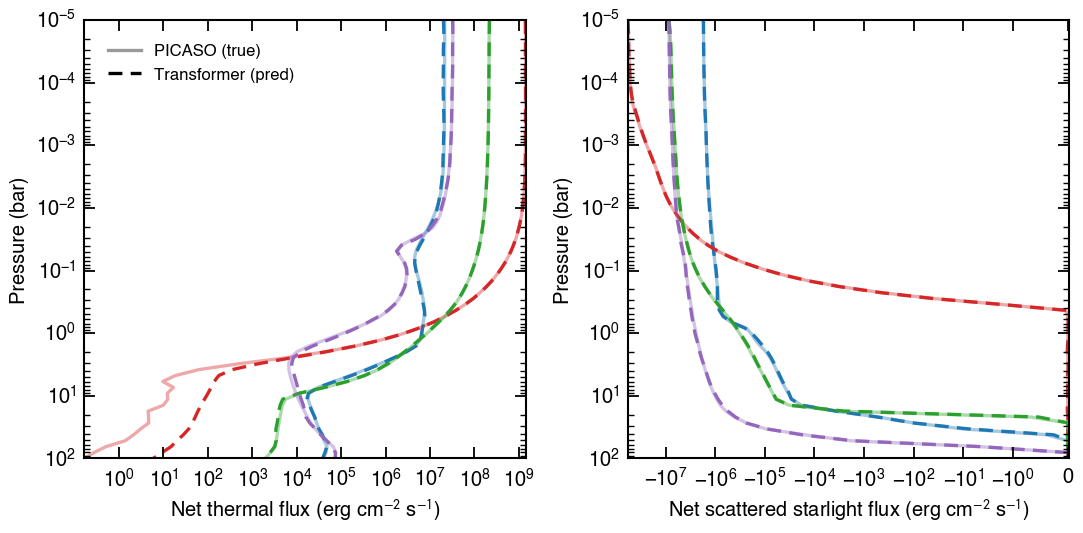

In [8]:
if MODEL_PRESENT:
    from torch.utils.data import DataLoader
    from dataset import create_collate_fn, create_dataset
    from normalizer import DataNormalizer

    NUM_PROFILES_TO_PLOT = 4
    PROFILE_LINE_COLORS = ("#1f77b4", "#d62728", "#2ca02c", "#9467bd")
    START_INDEX = 0


    def denormalize_channel(values: Tensor, var_name: str, norm_meta: Dict[str, Any]) -> Tensor:
        method = norm_meta["normalization_methods"][var_name]
        stats = norm_meta["per_key_stats"][var_name]
        if method != "bool" and stats:
            return DataNormalizer.denormalize_tensor(values, method, stats)
        return values


    def denormalize_batch(config, norm_meta, inputs_norm, masks, targets_norm, target_masks):
        ds = config["data_specification"]
        in_vars, glob_vars, tgt_vars = ds["input_variables"], ds["global_variables"], ds["target_variables"]
        pad = float(ds["padding_value"])
        seq_norm = inputs_norm["sequence"].to(dtype=torch.float32)
        seq_mask = masks["sequence"].bool()
        seq_phys = torch.empty_like(seq_norm)
        for j, n in enumerate(in_vars):
            seq_phys[..., j] = denormalize_channel(seq_norm[..., j], n, norm_meta).to(torch.float32)
        seq_phys[seq_mask] = pad
        glob_phys = None
        if glob_vars and "global_features" in inputs_norm:
            gn = inputs_norm["global_features"].to(torch.float32)
            glob_phys = torch.empty_like(gn)
            for j, n in enumerate(glob_vars):
                glob_phys[..., j] = denormalize_channel(gn[..., j], n, norm_meta).to(torch.float32)
        tgt_phys = torch.empty_like(targets_norm.to(torch.float32))
        tgt_mask = target_masks.bool()
        for j, n in enumerate(tgt_vars):
            tgt_phys[..., j] = denormalize_channel(targets_norm[..., j].to(torch.float32), n, norm_meta).to(torch.float32)
        tgt_phys[tgt_mask] = pad
        return seq_phys, glob_phys, tgt_phys, tgt_mask


    norm_meta = json.load(open(NORM_META_PATH, "r"))
    padding_value = float(train_config["data_specification"]["padding_value"])
    padding_epsilon = float(train_config["normalization"]["padding_comparison_epsilon"])

    with (PROC_TEST / "metadata.json").open("r") as f:
        test_total = int(json.load(f)["total_samples"])

    selected = list(range(START_INDEX, min(START_INDEX + NUM_PROFILES_TO_PLOT, test_total)))
    ds_obj = create_dataset(PROC_TEST, train_config, indices=selected)
    loader = DataLoader(
        ds_obj, batch_size=len(selected), shuffle=False,
        collate_fn=create_collate_fn(padding_value, padding_epsilon),
    )
    inputs_norm, masks, targets_norm, target_masks = next(iter(loader))
    seq_phys, glob_phys, tgt_phys, tgt_mask = denormalize_batch(
        train_config, norm_meta, inputs_norm, masks, targets_norm, target_masks,
    )

    # Load .pt2 program once and reuse module
    program = torch.export.load(str(STANDALONE_PT2))
    model = program.module().to('cpu')

    with torch.inference_mode():
        pred_phys = model(
            sequence_phys=seq_phys.to(torch.float32).cpu(),
            global_features_phys=(glob_phys.to(torch.float32).cpu() if glob_phys is not None else None),
        )

    input_vars = train_config["data_specification"]["input_variables"]
    target_vars = train_config["data_specification"]["target_variables"]
    pressure_idx = input_vars.index("pressure_bar") if "pressure_bar" in input_vars else None
    thermal_idx = target_vars.index("net_thermal_flux") if "net_thermal_flux" in target_vars else None
    reflected_idx = target_vars.index("net_reflected_flux") if "net_reflected_flux" in target_vars else None

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim
    for _ax in (plt.gcf().axes):
        _ax.grid(False, which="both")
    ax_t, ax_r = axes
    for k, sample_idx in enumerate(selected):
        valid = (~tgt_mask[k]).cpu().numpy()
        if not valid.any():
            continue
        p = pred_phys[k].cpu().numpy()[valid]
        t = tgt_phys[k].cpu().numpy()[valid]
        pr_vals = seq_phys[k, :, pressure_idx].cpu().numpy()[valid] if pressure_idx is not None else np.arange(valid.sum())
        color = PROFILE_LINE_COLORS[k % len(PROFILE_LINE_COLORS)]
        if thermal_idx is not None:
            yt_t, yt_p = t[:, thermal_idx], p[:, thermal_idx]
            pos = (yt_t > 0) & (yt_p > 0)
            if pos.any():
                ax_t.plot(yt_t[pos], pr_vals[pos], color=color, alpha=0.4, linewidth=2.4)
                ax_t.plot(yt_p[pos], pr_vals[pos], color=color, linestyle=(0, (10, 6)), linewidth=2.4)
        if reflected_idx is not None:
            yr_t, yr_p = t[:, reflected_idx], p[:, reflected_idx]
            if yr_t.size > 0:
                ax_r.plot(yr_t, pr_vals, color=color, alpha=0.4, linewidth=2.4)
                ax_r.plot(yr_p, pr_vals, color=color, linestyle=(0, (10, 6)), linewidth=2.4)

    for ax, label in ((ax_t, "Net thermal flux (erg cm$^{-2}$ s$^{-1}$)"),
                       (ax_r, "Net scattered starlight flux (erg cm$^{-2}$ s$^{-1}$)")):
        # symlog so negative scattered-flux excursions stay on the plot.
        ax.set_xscale("symlog", linthresh=1.0)
        ax.set_yscale("log")
        ax.set_ylim(1e2, 1e-5)
        ax.set_ylabel("Pressure (bar)")
        ax.set_xlabel(label)
    ax_t.legend(
        handles=[
            Line2D([0], [0], color="black", alpha=0.4, linewidth=2.4, label="PICASO (true)"),
            Line2D([0], [0], color="black", linestyle=(0, (10, 6)), linewidth=2.4, label="Transformer (pred)"),
        ],
        loc="best",
    )
    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_profiles.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()
else:
    print('Skipped figure 10 (example test profiles) — needs trained model + .pt2 export.')


In [9]:
if MODEL_PRESENT:
    from tqdm import tqdm

    PCT_DENOM_FLOOR = 1.0
    ERR_BATCH_SIZE = 1024
    DEVICE_ERR = torch.device("cpu")
    ERR_MAX_BATCHES = int(os.environ.get("ERR_MAX_BATCHES", "50"))

    program_err = torch.export.load(str(STANDALONE_PT2))
    model_err = program_err.module().to(DEVICE_ERR)

    with (PROC_TEST / "metadata.json").open("r") as f:
        total_samples = int(json.load(f)["total_samples"])

    ds_full = create_dataset(PROC_TEST, train_config, list(range(total_samples)))
    loader_full = DataLoader(
        ds_full, batch_size=ERR_BATCH_SIZE, shuffle=False,
        collate_fn=create_collate_fn(padding_value, padding_epsilon), drop_last=False,
    )

    target_vars = train_config["data_specification"]["target_variables"]
    flux_vars = [n for n in ("net_thermal_flux", "net_reflected_flux") if n in target_vars]
    flux_idx = {n: target_vars.index(n) for n in flux_vars}

    acc = {n: {"diff_chunks": [], "true_chunks": [], "pred_chunks": [], "pressure_chunks": []} for n in flux_vars}
    input_vars = train_config["data_specification"]["input_variables"]
    pressure_idx = input_vars.index("pressure_bar") if "pressure_bar" in input_vars else None

    for b_idx, (inputs_norm, masks, targets_norm, target_masks) in enumerate(tqdm(loader_full, desc="Test batches")):
        if ERR_MAX_BATCHES and b_idx >= ERR_MAX_BATCHES:
            break
        seq_phys_b, glob_phys_b, tgt_phys_b, tgt_mask_b = denormalize_batch(
            train_config, norm_meta, inputs_norm, masks, targets_norm, target_masks,
        )
        with torch.inference_mode():
            pred_phys_b = model_err(
                sequence_phys=seq_phys_b.to(torch.float32).cpu(),
                global_features_phys=(glob_phys_b.to(torch.float32).cpu() if glob_phys_b is not None else None),
            )
        valid = (~tgt_mask_b)
        pressure_phys = seq_phys_b[..., pressure_idx] if pressure_idx is not None else None

        for n in flux_vars:
            i = flux_idx[n]
            p = pred_phys_b[..., i][valid]
            t = tgt_phys_b[..., i][valid]
            if p.numel() == 0:
                continue
            acc[n]["diff_chunks"].append((p - t).cpu().numpy())
            acc[n]["true_chunks"].append(t.cpu().numpy())
            acc[n]["pred_chunks"].append(p.cpu().numpy())
            if pressure_phys is not None:
                acc[n]["pressure_chunks"].append(pressure_phys[valid].cpu().numpy())

    per_channel = {}
    for n in flux_vars:
        diffs = np.concatenate(acc[n]["diff_chunks"]) if acc[n]["diff_chunks"] else np.array([])
        truths = np.concatenate(acc[n]["true_chunks"]) if acc[n]["true_chunks"] else np.array([])
        if diffs.size == 0:
            continue
        per_channel[n] = {
            "n_points": int(diffs.size),
            "mae": float(np.mean(np.abs(diffs))),
            "rmse": float(np.sqrt(np.mean(diffs ** 2))),
            "r2": float(1.0 - np.sum(diffs ** 2) / max(np.sum((truths - truths.mean()) ** 2), 1e-30)),
        }
    print("Per-channel test errors (in-memory only; not written to disk):")
    for n, s in per_channel.items():
        print(f"  {n}: MAE={s['mae']:.3e}, RMSE={s['rmse']:.3e}, R^2={s['r2']:.6f}")

    ERR_RAW = {
        n: {
            "diffs": np.concatenate(acc[n]["diff_chunks"]) if acc[n]["diff_chunks"] else np.array([]),
            "truths": np.concatenate(acc[n]["true_chunks"]) if acc[n]["true_chunks"] else np.array([]),
            "preds":  np.concatenate(acc[n]["pred_chunks"]) if acc[n]["pred_chunks"] else np.array([]),
            "pressures": np.concatenate(acc[n]["pressure_chunks"]) if acc[n]["pressure_chunks"] else np.array([]),
        }
        for n in flux_vars
    }
else:
    print("Skipped per-channel test-error computation - needs trained model + .pt2 export.")


Test batches:   7%|▋         | 50/727 [04:38<1:02:44,  5.56s/it]

Per-channel test errors (in-memory only; not written to disk):
  net_thermal_flux: MAE=2.836e+06, RMSE=8.260e+06, R^2=0.999799
  net_reflected_flux: MAE=1.580e+05, RMSE=4.950e+05, R^2=0.999838


## 15. Figure: residual + energy-balance diagnostic (R1.4, R1.5)

Top row: predicted-vs-true scatter with y=x line per channel. Bottom row: residual histogram per channel and a per-profile integrated-flux relative-error histogram (energy-balance check). Strengthens the no-memorization argument.

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_residuals.png


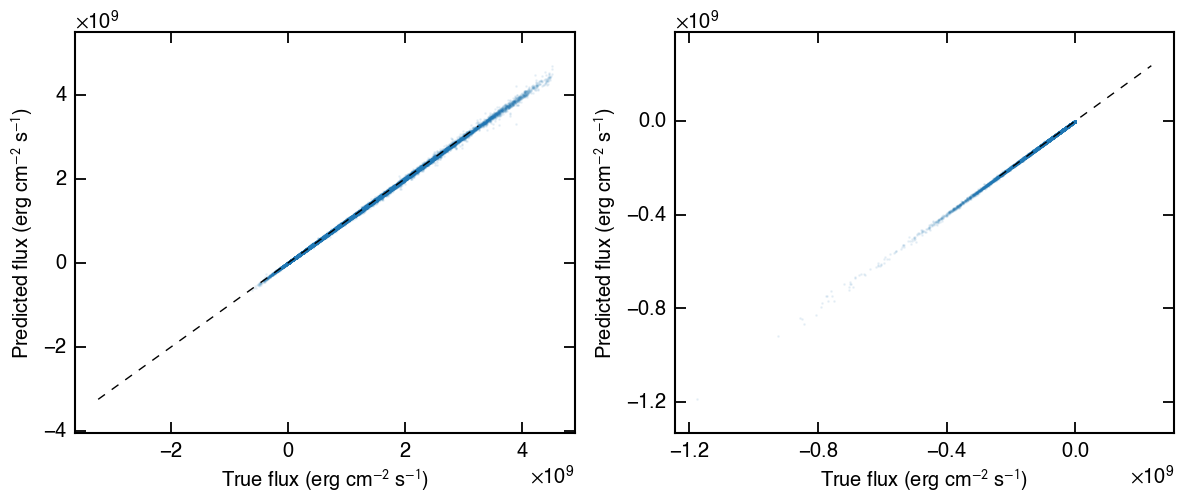

In [10]:
if MODEL_PRESENT:
    from matplotlib.ticker import MaxNLocator

    def downsample(arr: np.ndarray, n: int = 200_000, seed: int = 0) -> np.ndarray:
        if arr.size <= n:
            return arr
        rng = np.random.default_rng(seed)
        idx = rng.choice(arr.size, n, replace=False)
        return arr[idx]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim
    for _ax in (plt.gcf().axes):
        _ax.grid(False, which="both")

    for col, name, title in (
        (0, "net_thermal_flux", "Net thermal flux"),
        (1, "net_reflected_flux", "Net scattered starlight flux"),
    ):
        ax = axes[col]
        if name not in ERR_RAW or ERR_RAW[name]["truths"].size == 0:
            ax.set_axis_off()
            continue
        truths = downsample(ERR_RAW[name]["truths"])
        preds = downsample(ERR_RAW[name]["preds"])

        ax.scatter(truths, preds, s=1, alpha=0.07, color="#1f77b4")
        lim = float(np.percentile(np.abs(np.concatenate([truths, preds])), 99.5))
        if np.isfinite(lim) and lim > 0:
            ax.plot([-lim, lim], [-lim, lim], color="black", linewidth=1.0, linestyle="--")

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.grid(False)
        ax.set_xlabel("True flux (erg cm$^{-2}$ s$^{-1}$)")
        ax.set_ylabel("Predicted flux (erg cm$^{-2}$ s$^{-1}$)")

    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_residuals.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()
else:
    print("Skipped residual diagnostic - needs ERR_RAW from previous section.")


## 17. Sanity assertions and READY gate

## Training curves (SAFE-paper style)


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/training_curves.png


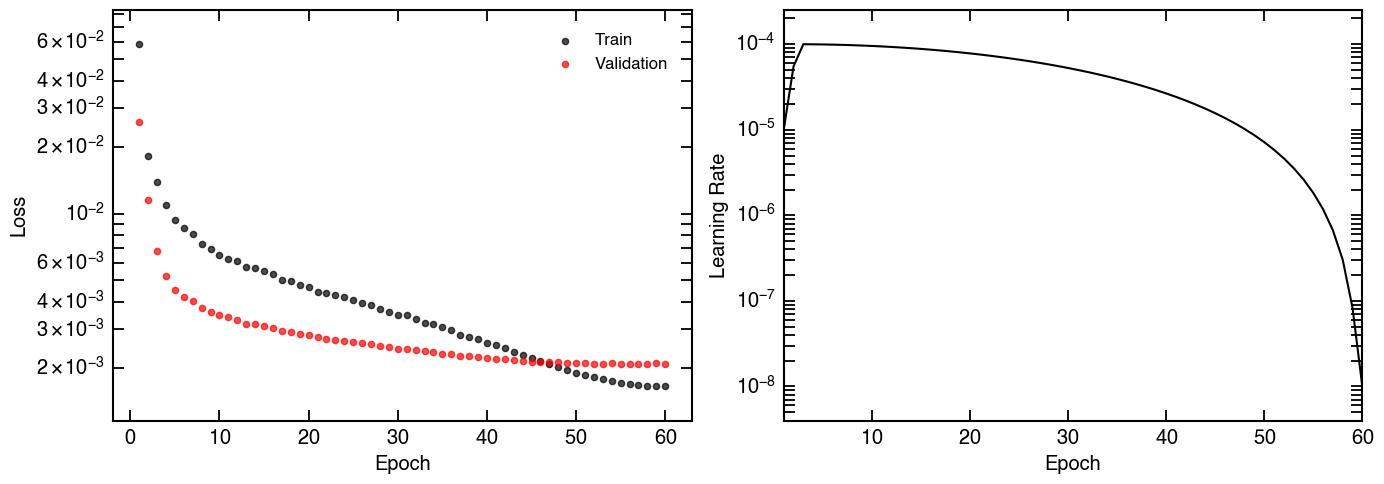

In [11]:
if MODEL_PRESENT:
    df_tc = training_log.copy()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.scatter(df_tc["epoch"], df_tc["train_loss"], color="black", label="Train", alpha=0.7)
    ax1.scatter(df_tc["epoch"], df_tc["val_loss"], color="red", label="Validation", alpha=0.7)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_yscale("log")
    fix_log_ticks(ax1, axis="y")
    ax1.legend()
    ax2.plot(df_tc["epoch"], df_tc["lr"], color="black")
    ax2.set_yscale("log")
    fix_log_ticks(ax2, axis="y")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning Rate")
    plt.tight_layout()
    out = FIGS_DIR / "training_curves.png"
    plt.savefig(out, dpi=150)
    print(f"Saved: {out}")
    plt.show()
else:
    print("Skipped training_curves.png — needs trained model.")


## Atmospheric profiles 3-panel (raw H5, no predictions)


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/atmospheric_profiles_3panel.png


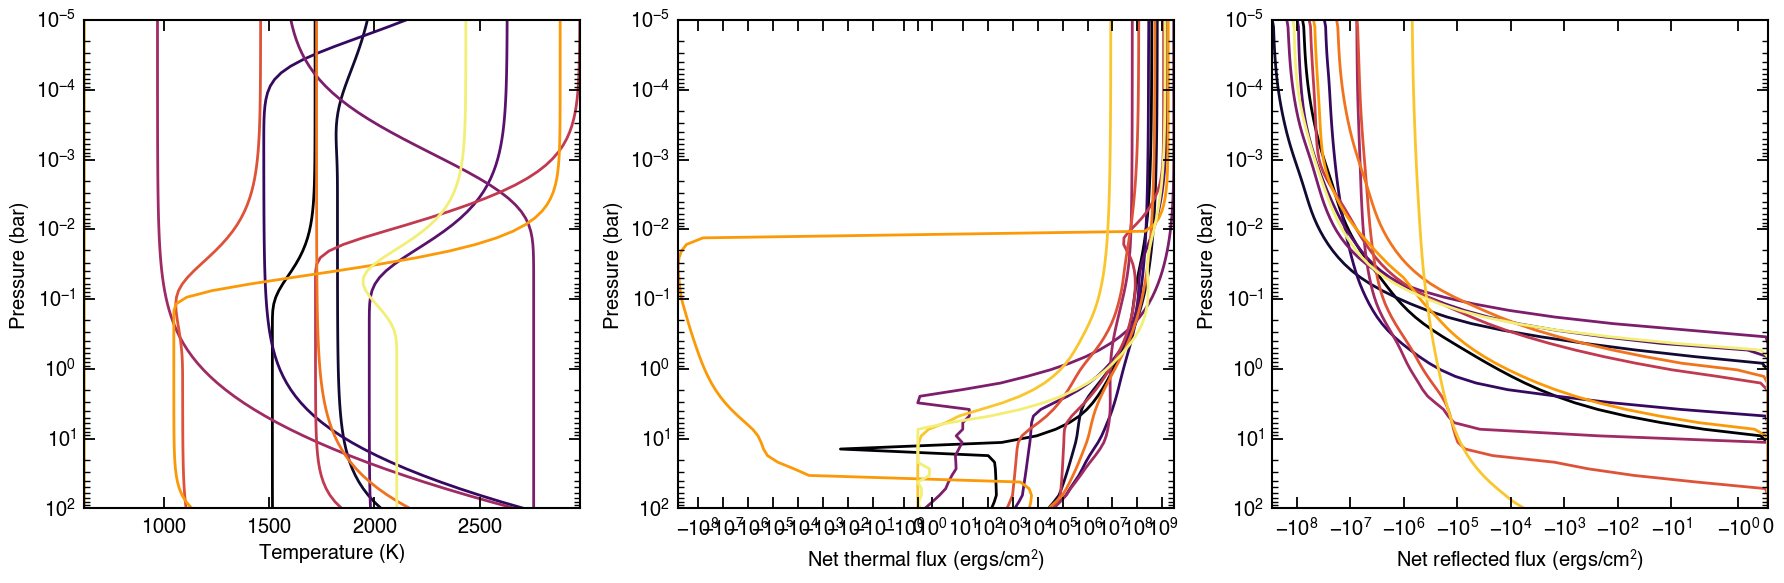

In [12]:
import h5py

PROFILE_INDICES = [0, 2, 3, 4, 6, 7, 8, 10, 12, 17, 18, 20]

with open(MODEL_DIR / "dataset_splits.json") as _f:
    _splits = json.load(_f)
if "file_stems" in _splits:
    _stems = _splits["file_stems"]
    test_pairs = [(_stems[s], i) for s, i in _splits["test"]]
else:
    test_pairs = _splits["test"]
h5_files = train_config["data_paths_config"]["hdf5_dataset_filename"]
if isinstance(h5_files, str):
    h5_files = [h5_files]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
(axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim
for _ax in (plt.gcf().axes):
    _ax.grid(False, which="both")
colors = plt.cm.inferno(np.linspace(0, 0.95, len(PROFILE_INDICES)))

for plot_idx, profile_idx in enumerate(PROFILE_INDICES):
    if profile_idx >= len(test_pairs):
        continue
    stem, row = test_pairs[profile_idx]
    h5_match = next((h for h in h5_files if Path(h).stem == stem), h5_files[0])
    h5_path = PROJECT_ROOT / "data" / "raw" / h5_match
    if not h5_path.exists():
        continue
    with h5py.File(h5_path, "r") as f:
        T = f["temperature_k"][row]
        P = f["pressure_bar"][row]
        thermal = f["net_thermal_flux"][row]
        reflected = f["net_reflected_flux"][row]
    valid = (P > 0) & np.isfinite(P) & np.isfinite(T)
    axes[0].plot(T[valid], P[valid], color=colors[plot_idx], linewidth=2.0, label=f"#{profile_idx}")
    axes[1].plot(thermal[valid], P[valid], color=colors[plot_idx], linewidth=2.0)
    axes[2].plot(reflected[valid], P[valid], color=colors[plot_idx], linewidth=2.0)

axes[0].set_yscale("log"); axes[0].set_ylim(1e2, 1e-5)
axes[0].set_xlabel("Temperature (K)"); axes[0].set_ylabel("Pressure (bar)")
axes[1].set_yscale("log"); axes[1].set_xscale("symlog", base=10); axes[1].set_ylim(1e2, 1e-5)
axes[1].set_xlabel("Net thermal flux (ergs/cm$^2$)"); axes[1].set_ylabel("Pressure (bar)")
axes[2].set_yscale("log"); axes[2].set_xscale("symlog", base=10); axes[2].set_ylim(1e2, 1e-5)
axes[2].set_xlabel("Net reflected flux (ergs/cm$^2$)"); axes[2].set_ylabel("Pressure (bar)")
for ax in axes:
    pass
plt.tight_layout()
out = FIGS_DIR / "atmospheric_profiles_3panel.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()


## Atmospheric profiles 3-panel with predictions


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/atmospheric_profiles_3panel_with_preds.png


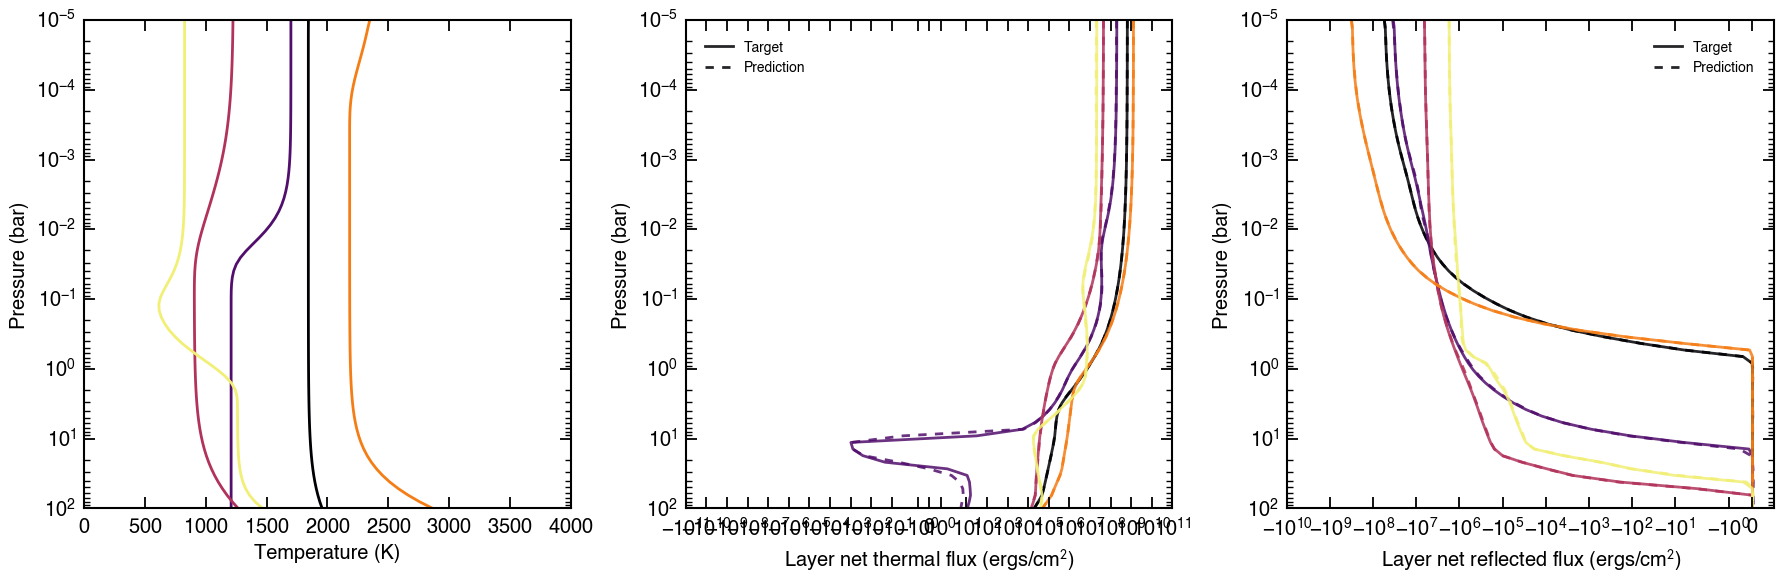

In [13]:
if MODEL_PRESENT:
    import h5py

    OOPS_PROFILE_INDICES = [0, 2, 3, 4, 6]
    h5_path_main = PROJECT_ROOT / "data" / "raw" / h5_files[0]
    max_len = int(train_config["model_hyperparameters"]["max_sequence_length"])
    in_vars = train_config["data_specification"]["input_variables"]
    glob_vars = train_config["data_specification"]["global_variables"]
    tgt_vars = train_config["data_specification"]["target_variables"]
    pad_v = float(train_config["data_specification"]["padding_value"])
    thermal_idx = tgt_vars.index("net_thermal_flux")
    reflected_idx = tgt_vars.index("net_reflected_flux")

    program_oops = torch.export.load(str(STANDALONE_PT2))
    model_oops = program_oops.module().to("cpu")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim
    for _ax in (plt.gcf().axes):
        _ax.grid(False, which="both")
    colors = plt.cm.inferno(np.linspace(0, 0.95, len(OOPS_PROFILE_INDICES)))

    with h5py.File(h5_path_main, "r") as hf:
        for j, idx in enumerate(OOPS_PROFILE_INDICES):
            if idx >= hf[in_vars[0]].shape[0]:
                continue
            color = colors[j]
            seq = np.stack([hf[v][idx] for v in in_vars], axis=-1).astype(np.float32)
            seq_t = torch.from_numpy(seq).unsqueeze(0)
            if seq_t.shape[1] < max_len:
                pad_shape = (seq_t.shape[0], max_len - seq_t.shape[1], seq_t.shape[2])
                seq_t = torch.cat([seq_t, torch.full(pad_shape, pad_v)], dim=1)
            glb = None
            if glob_vars:
                glb_vals = np.array([hf[v][idx] for v in glob_vars], dtype=np.float32).reshape(1, -1)
                glb = torch.from_numpy(glb_vals)
            with torch.inference_mode():
                pred = model_oops(sequence_phys=seq_t.cpu(),
                                   global_features_phys=glb.cpu() if glb is not None else None)
            pred_np = pred.cpu().numpy()[0]
            L_real = hf[in_vars[0]][idx].shape[0]
            P = hf["pressure_bar"][idx]
            T = hf["temperature_k"][idx]
            targ_th = hf["net_thermal_flux"][idx]
            targ_rf = hf["net_reflected_flux"][idx]
            pred_th = pred_np[:L_real, thermal_idx]
            pred_rf = pred_np[:L_real, reflected_idx]
            v = (P > 0) & np.isfinite(P) & np.isfinite(T)
            axes[0].plot(T[v], P[v], color=color, linewidth=2.0, label=f"Profile {idx}")
            axes[1].plot(targ_th[v], P[v], "-", color=color, linewidth=2.0, alpha=0.85,
                         label="Target" if j == 0 else None)
            axes[1].plot(pred_th[v], P[v], "--", color=color, linewidth=2.0, alpha=0.85,
                         label="Prediction" if j == 0 else None)
            axes[2].plot(targ_rf[v], P[v], "-", color=color, linewidth=2.0, alpha=0.85,
                         label="Target" if j == 0 else None)
            axes[2].plot(pred_rf[v], P[v], "--", color=color, linewidth=2.0, alpha=0.85,
                         label="Prediction" if j == 0 else None)

    axes[0].set_yscale("log"); axes[0].set_xlim(0, 4000); axes[0].set_ylim(1e2, 1e-5)
    axes[0].set_xlabel("Temperature (K)"); axes[0].set_ylabel("Pressure (bar)")
    axes[1].set_yscale("log"); axes[1].set_xscale("symlog", base=10); axes[1].set_ylim(1e2, 1e-5)
    axes[1].set_xlim(-1e11, 1e11)
    axes[1].set_xlabel("Layer net thermal flux (ergs/cm$^2$)"); axes[1].set_ylabel("Pressure (bar)")
    axes[1].legend(fontsize=10, loc="best")
    axes[2].set_yscale("log"); axes[2].set_xscale("symlog"); axes[2].set_ylim(1e2, 1e-5)
    axes[2].set_xlim(-1e10, 0.9)
    axes[2].set_xlabel("Layer net reflected flux (ergs/cm$^2$)"); axes[2].set_ylabel("Pressure (bar)")
    axes[2].legend(fontsize=10, loc="best")
    for ax in axes:
        pass
    plt.tight_layout()
    out = FIGS_DIR / "atmospheric_profiles_3panel_with_preds.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()
else:
    print("Skipped atmospheric_profiles_3panel_with_preds.png — needs trained model.")


## Flux predictions per sample (2×2 grid)


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/flux_predictions_samples.png


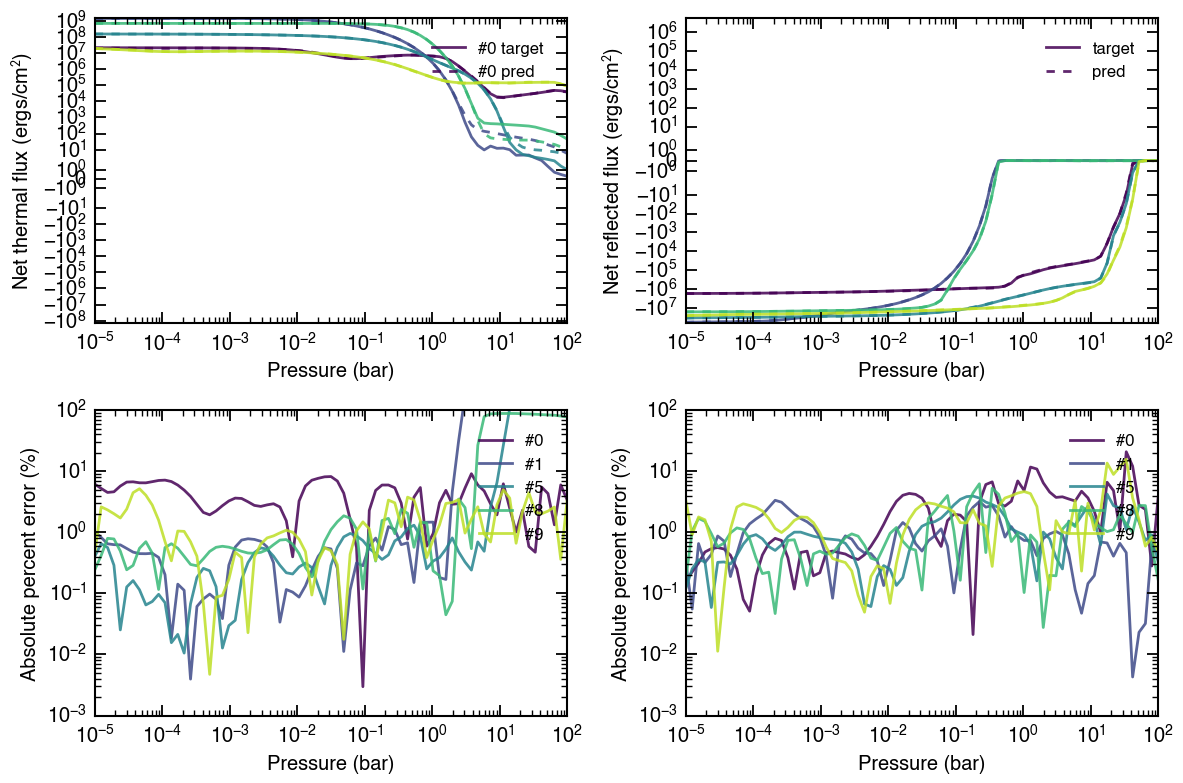

In [14]:
if MODEL_PRESENT:
    SAMPLE_INDICES = [0, 1, 5, 8, 9]
    program_fp = torch.export.load(str(STANDALONE_PT2))
    model_fp = program_fp.module().to("cpu")

    pad_val = float(train_config["data_specification"]["padding_value"])
    pad_eps = float(train_config["normalization"]["padding_comparison_epsilon"])
    ds_fp = create_dataset(PROC_TEST, train_config, list(range(max(SAMPLE_INDICES) + 1)))
    in_vars_fp = train_config["data_specification"]["input_variables"]
    tgt_vars_fp = train_config["data_specification"]["target_variables"]
    p_idx_fp = in_vars_fp.index("pressure_bar")
    th_idx = tgt_vars_fp.index("net_thermal_flux")
    rf_idx = tgt_vars_fp.index("net_reflected_flux")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim
    for _ax in (plt.gcf().axes):
        _ax.grid(False, which="both")
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(SAMPLE_INDICES)))

    for k, sample_idx in enumerate(SAMPLE_INDICES):
        from torch.utils.data import DataLoader as _DL
        loader = _DL(create_dataset(PROC_TEST, train_config, [sample_idx]),
                     batch_size=1, shuffle=False,
                     collate_fn=create_collate_fn(pad_val, pad_eps))
        bi, bm, bt, btm = next(iter(loader))
        sp, gp, tp, tm = denormalize_batch(train_config, norm_meta, bi, bm, bt, btm)
        with torch.inference_mode():
            pp = model_fp(sequence_phys=sp.cpu(),
                          global_features_phys=gp.cpu() if gp is not None else None)
        valid_k = (~tm[0]).cpu().numpy()
        pr = sp[0, :, p_idx_fp].cpu().numpy()[valid_k]
        th_t = tp[0, :, th_idx].cpu().numpy()[valid_k]
        th_p = pp[0, :, th_idx].cpu().numpy()[valid_k]
        rf_t = tp[0, :, rf_idx].cpu().numpy()[valid_k]
        rf_p = pp[0, :, rf_idx].cpu().numpy()[valid_k]
        th_err = 100 * np.abs(th_p - th_t) / np.maximum(np.abs(th_t), 1.0)
        rf_err = 100 * np.abs(rf_p - rf_t) / np.maximum(np.abs(rf_t), 1.0)
        c = colors[k]
        axes[0, 0].plot(pr, th_t, "-", color=c, linewidth=2.0, alpha=0.85,
                        label=f"#{sample_idx} target" if k == 0 else None)
        axes[0, 0].plot(pr, th_p, "--", color=c, linewidth=2.0, alpha=0.85,
                        label=f"#{sample_idx} pred" if k == 0 else None)
        axes[1, 0].plot(pr, th_err, color=c, linewidth=2.0, alpha=0.85, label=f"#{sample_idx}")
        axes[0, 1].plot(pr, rf_t, "-", color=c, linewidth=2.0, alpha=0.85,
                        label="target" if k == 0 else None)
        axes[0, 1].plot(pr, rf_p, "--", color=c, linewidth=2.0, alpha=0.85,
                        label="pred" if k == 0 else None)
        axes[1, 1].plot(pr, rf_err, color=c, linewidth=2.0, alpha=0.85, label=f"#{sample_idx}")

    for ax in axes.flat:
        ax.set_xscale("log")
    axes[0, 0].set_yscale("symlog"); axes[0, 0].set_xlabel("Pressure (bar)")
    axes[0, 0].set_ylabel("Net thermal flux (ergs/cm$^2$)"); axes[0, 0].legend()
    axes[1, 0].set_yscale("log"); axes[1, 0].set_xlabel("Pressure (bar)")
    axes[1, 0].set_ylabel("Absolute percent error (%)"); axes[1, 0].set_ylim(1e-3, 100); axes[1, 0].legend()
    axes[0, 1].set_yscale("symlog"); axes[0, 1].set_xlabel("Pressure (bar)")
    axes[0, 1].set_ylabel("Net reflected flux (ergs/cm$^2$)"); axes[0, 1].legend()
    axes[1, 1].set_yscale("log"); axes[1, 1].set_xlabel("Pressure (bar)")
    axes[1, 1].set_ylabel("Absolute percent error (%)"); axes[1, 1].set_ylim(1e-3, 100); axes[1, 1].legend()
    plt.tight_layout()
    out = FIGS_DIR / "flux_predictions_samples.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()
else:
    print("Skipped flux_predictions_samples.png — needs trained model.")


## Predicted vs actual flux (log-log scatter)


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/predicted_vs_actual.png


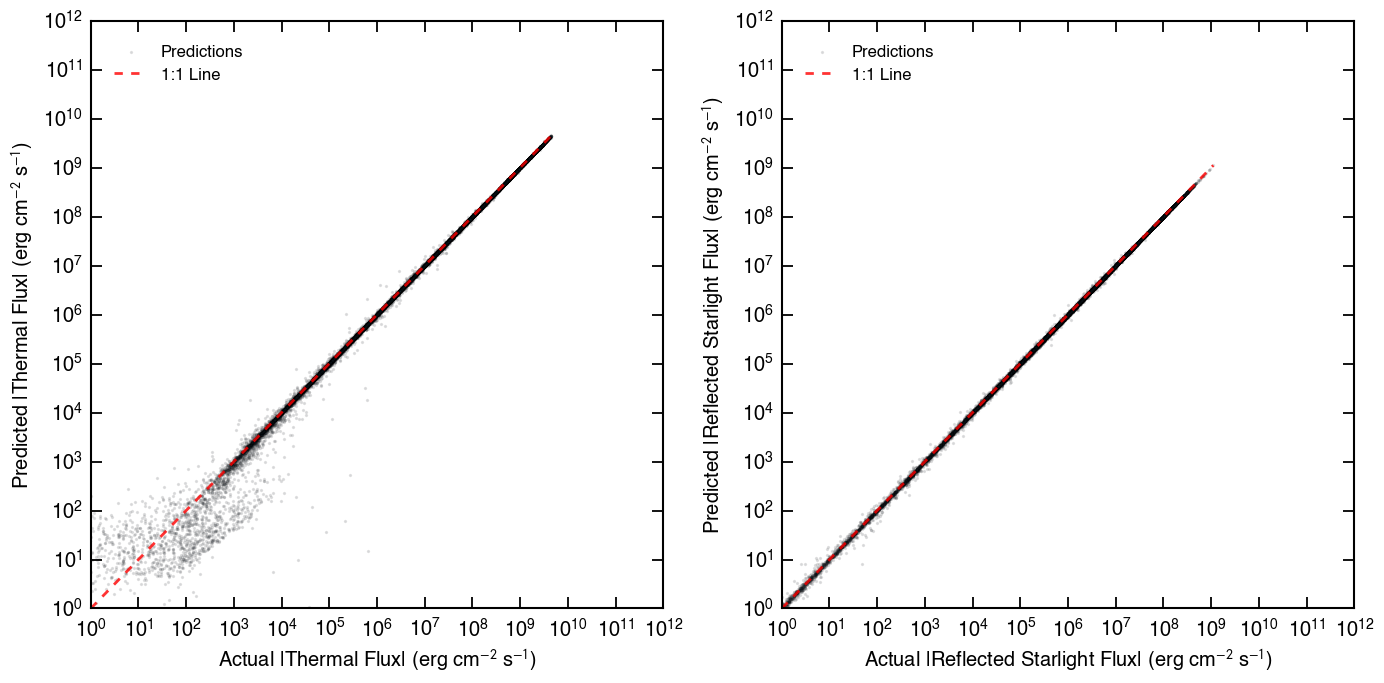

In [15]:
if MODEL_PRESENT and "ERR_RAW" in dir():
    flux_names = list(ERR_RAW.keys())
    fig, axes = plt.subplots(1, len(flux_names), figsize=(14, 7), sharey=False)
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim
    for _ax in (plt.gcf().axes):
        _ax.grid(False, which="both")
    if len(flux_names) == 1:
        axes = [axes]
    for ax, name in zip(axes, flux_names):
        t = np.abs(ERR_RAW[name]["truths"])
        p = np.abs(ERR_RAW[name]["preds"])
        sel = (t > 0) & (p > 0)
        t, p = t[sel], p[sel]
        if t.size > 50_000:
            rng = np.random.default_rng(0)
            i = rng.choice(t.size, 50_000, replace=False)
            t, p = t[i], p[i]
        ax.scatter(t, p, alpha=0.1, s=2, c="#2C3E50", label="Predictions")
        vmin = max(min(t.min(), p.min()), 1.0)
        vmax = max(t.max(), p.max())
        ax.plot([vmin, vmax], [vmin, vmax], "r--", linewidth=2, label="1:1 Line", alpha=0.8)
        label = "Thermal" if name == "net_thermal_flux" else "Reflected Starlight"
        ax.set_xlabel(f"Actual |{label} Flux| (erg cm$^{{-2}}$ s$^{{-1}}$)")
        ax.set_ylabel(f"Predicted |{label} Flux| (erg cm$^{{-2}}$ s$^{{-1}}$)")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(1, 1e12); ax.set_ylim(1, 1e12)
        ax.legend(loc="upper left")
    plt.tight_layout()
    out = FIGS_DIR / "predicted_vs_actual.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out}")
    plt.show()
else:
    print("Skipped predicted_vs_actual.png — needs ERR_RAW.")


## Pressure-binned signed % error (pastel bands)


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/pressure_error_pastel_bands.png


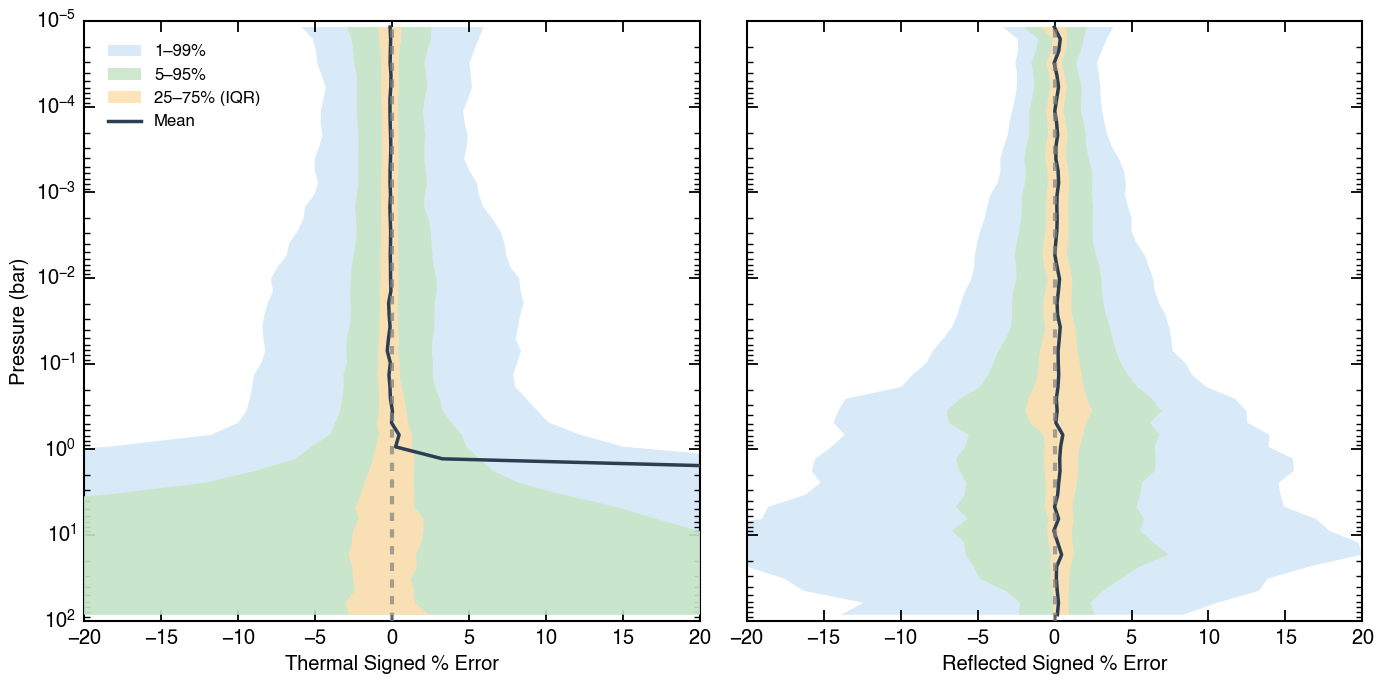

In [16]:
if MODEL_PRESENT and "ERR_RAW" in dir():
    BAND_1 = "#D4E8F7"
    BAND_5 = "#C8E6C9"
    BAND_25 = "#FFE0B2"
    MEAN_LINE = "#2C3E50"
    flux_names = list(ERR_RAW.keys())

    fig, axes = plt.subplots(1, len(flux_names), figsize=(14, 7), sharey=True, sharex=True)
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim
    for _ax in (plt.gcf().axes):
        _ax.grid(False, which="both")
    if len(flux_names) == 1:
        axes = [axes]

    for ax, name in zip(axes, flux_names):
        prs = ERR_RAW[name]["pressures"]
        diffs = ERR_RAW[name]["diffs"]
        truths = ERR_RAW[name]["truths"]
        denom = np.maximum(np.abs(truths), 1.0)
        signed_pct = 100.0 * diffs / denom
        sel = prs > 0
        prs, signed_pct = prs[sel], signed_pct[sel]
        if prs.size == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue
        n_bins = 50
        bins = np.logspace(np.log10(prs.min()), np.log10(prs.max()), n_bins + 1)
        idxs = np.digitize(prs, bins, right=False) - 1
        keep = (idxs >= 0) & (idxs < n_bins)
        prs, signed_pct, idxs = prs[keep], signed_pct[keep], idxs[keep]
        centers, means, q25, q75, q05, q95, q01, q99 = [], [], [], [], [], [], [], []
        for i in range(n_bins):
            bsel = idxs == i
            if bsel.sum() < 3:
                continue
            vals = signed_pct[bsel]
            centers.append(float(np.sqrt(bins[i] * bins[i + 1])))
            means.append(float(np.mean(vals)))
            q25.append(float(np.percentile(vals, 25)))
            q75.append(float(np.percentile(vals, 75)))
            q05.append(float(np.percentile(vals, 5)))
            q95.append(float(np.percentile(vals, 95)))
            q01.append(float(np.percentile(vals, 1)))
            q99.append(float(np.percentile(vals, 99)))
        centers = np.array(centers)
        ax.fill_betweenx(centers, q01, q99, color=BAND_1, alpha=0.9, edgecolor="none", label="1–99%", zorder=2)
        ax.fill_betweenx(centers, q05, q95, color=BAND_5, alpha=0.9, edgecolor="none", label="5–95%", zorder=3)
        ax.fill_betweenx(centers, q25, q75, color=BAND_25, alpha=0.9, edgecolor="none", label="25–75% (IQR)", zorder=4)
        ax.plot(means, centers, color=MEAN_LINE, linewidth=2.5, label="Mean", zorder=5)
        ax.axvline(0.0, color="gray", linestyle="dashed", linewidth=3.0, alpha=0.7, zorder=10)
        label = "Thermal" if name == "net_thermal_flux" else "Reflected"
        ax.set_xlabel(f"{label} Signed % Error")
        if ax is axes[0]:
            ax.legend(loc="upper left", framealpha=0.95, fancybox=True, shadow=True)
    axes[0].set_ylabel("Pressure (bar)")
    for ax in axes:
        ax.set_yscale("log"); ax.set_ylim(1e2, 1e-5); ax.set_xlim(-20, 20)
    plt.tight_layout()
    out = FIGS_DIR / "pressure_error_pastel_bands.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out}")
    plt.show()
else:
    print("Skipped pressure_error_pastel_bands.png — needs ERR_RAW.")


## Eager-model inference throughput vs batch size


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/benchmark_throughput.png


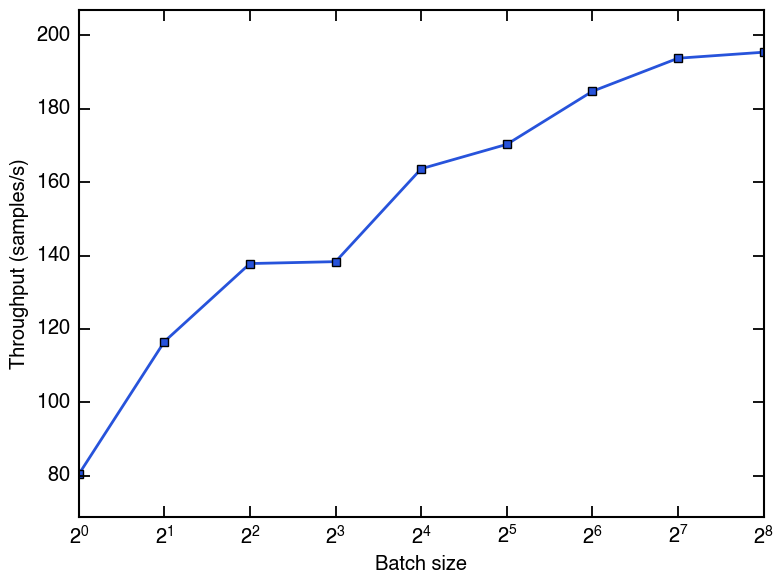

In [17]:
if MODEL_PRESENT:
    from model import create_prediction_model
    BENCH_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
    WARMUP_CALLS = 10
    REPEATS_BENCH = 5
    CALLS_PER = 3

    torch.set_default_device("cpu")
    bench_model = create_prediction_model(config=train_config, device=torch.device("cpu"), compile_model=False).eval()
    ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location="cpu", weights_only=False)
    state = ckpt["state_dict"]
    if any(k.startswith("_orig_mod.") for k in state):
        state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
    bench_model.load_state_dict(state, strict=True)
    bench_model = bench_model.to("cpu", dtype=torch.float32).eval()

    seq_len_b = int(train_config["model_hyperparameters"]["max_sequence_length"])
    in_dim_b = len(train_config["data_specification"]["input_variables"])
    g_dim_b = len(train_config["data_specification"]["global_variables"])

    mean_ms, std_ms = [], []
    for B in BENCH_BATCH_SIZES:
        seq = torch.randn(B, seq_len_b, in_dim_b, dtype=torch.float32)
        msk = torch.zeros(B, seq_len_b, dtype=torch.bool)
        glob = torch.randn(B, g_dim_b, dtype=torch.float32) if g_dim_b > 0 else None
        with torch.inference_mode():
            for _ in range(WARMUP_CALLS):
                bench_model(seq, glob, msk)
            ts = []
            for _ in range(REPEATS_BENCH):
                t0 = time.perf_counter_ns()
                for _ in range(CALLS_PER):
                    bench_model(seq, glob, msk)
                dt = (time.perf_counter_ns() - t0) / 1e6
                ts.append(dt / CALLS_PER)
        a = np.asarray(ts)
        mean_ms.append(float(a.mean())); std_ms.append(float(a.std(ddof=1) if a.size > 1 else 0.0))

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    (ax if isinstance(ax, np.ndarray) else np.array([ax])).ravel()  # no-op shim
    for _ax in (plt.gcf().axes):
        _ax.grid(False, which="both")
    tput = [B / (m / 1000.0) for B, m in zip(BENCH_BATCH_SIZES, mean_ms)]
    ax.plot(BENCH_BATCH_SIZES, tput, marker="s", markersize=6, linewidth=2)
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Batch size")
    ax.set_ylabel("Throughput (samples/s)")
    plt.tight_layout()
    out = FIGS_DIR / "benchmark_throughput.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()
else:
    print("Skipped benchmark_throughput.png — needs trained model.")


## Roth-dataset profiles + errors


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/roth_h5_flux_and_PT.png


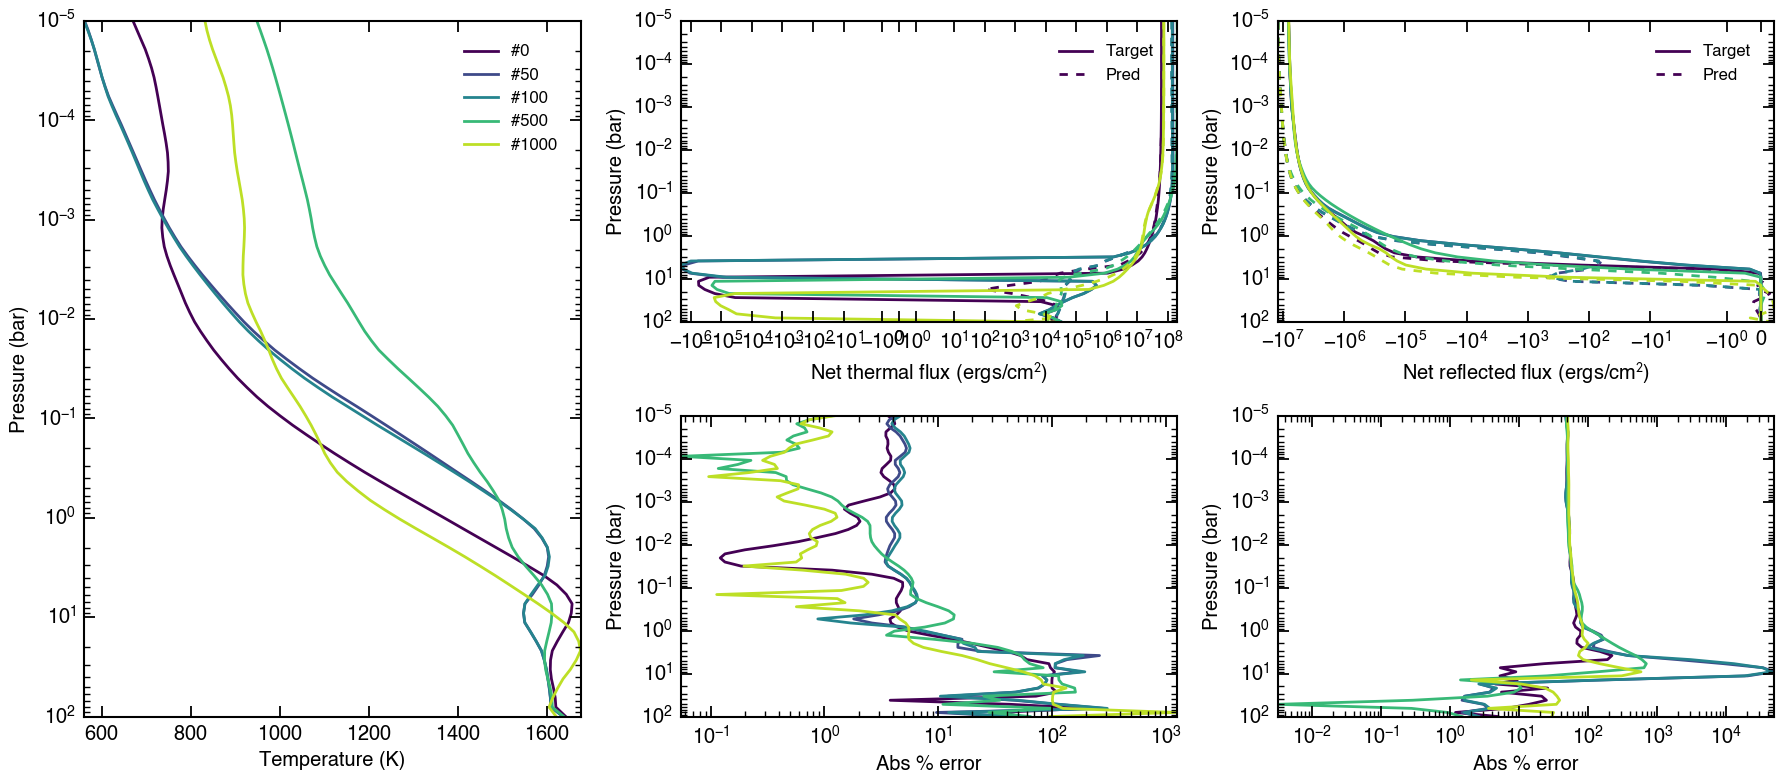

In [18]:
if MODEL_PRESENT:
    import h5py
    ROTH_H5 = PROJECT_ROOT.parent / "Problemulator_SAFE_PAPER_VERSION" / "testing" / "roth" / "picaso_results_roth.h5"
    if ROTH_H5.exists():
        ROTH_INDICES = [0, 50, 100, 500, 1000]
        in_vars_r = train_config["data_specification"]["input_variables"]
        glob_vars_r = train_config["data_specification"]["global_variables"]
        tgt_vars_r = train_config["data_specification"]["target_variables"]
        pad_v_r = float(train_config["data_specification"]["padding_value"])
        max_len_r = int(train_config["model_hyperparameters"]["max_sequence_length"])
        th_i = tgt_vars_r.index("net_thermal_flux")
        rf_i = tgt_vars_r.index("net_reflected_flux")

        program_r = torch.export.load(str(STANDALONE_PT2))
        model_r = program_r.module().to("cpu")

        from matplotlib.gridspec import GridSpec
        fig = plt.figure(figsize=(18, 8))
        gs = GridSpec(2, 3, figure=fig)
        ax_pt = fig.add_subplot(gs[:, 0])
        ax_th = fig.add_subplot(gs[0, 1])
        ax_th_err = fig.add_subplot(gs[1, 1])
        ax_rf = fig.add_subplot(gs[0, 2])
        ax_rf_err = fig.add_subplot(gs[1, 2])
        colors_r = plt.cm.viridis(np.linspace(0, 0.9, len(ROTH_INDICES)))

        with h5py.File(ROTH_H5, "r") as hf:
            for j, idx in enumerate(ROTH_INDICES):
                color = colors_r[j]
                seq = np.stack([hf[v][idx] for v in in_vars_r], axis=-1).astype(np.float32)
                seq_t = torch.from_numpy(seq).unsqueeze(0)
                L_real = seq_t.shape[1]
                if L_real < max_len_r:
                    pad_shape = (seq_t.shape[0], max_len_r - L_real, seq_t.shape[2])
                    seq_t = torch.cat([seq_t, torch.full(pad_shape, pad_v_r)], dim=1)
                glb = None
                if glob_vars_r:
                    glb_vals = np.array([hf[v][idx] for v in glob_vars_r], dtype=np.float32).reshape(1, -1)
                    glb = torch.from_numpy(glb_vals)
                with torch.inference_mode():
                    pred = model_r(sequence_phys=seq_t.cpu(),
                                    global_features_phys=glb.cpu() if glb is not None else None)
                pred_np = pred.cpu().numpy()[0, :L_real]
                P = hf["pressure_bar"][idx]
                T = hf["temperature_k"][idx]
                th_t = hf["net_thermal_flux"][idx]
                rf_t = hf["net_reflected_flux"][idx]
                th_p = pred_np[:, th_i]
                rf_p = pred_np[:, rf_i]
                v = (P > 0) & np.isfinite(P) & np.isfinite(T)
                ax_pt.plot(T[v], P[v], color=color, linewidth=2.0, label=f"#{idx}")
                ax_th.plot(th_t[v], P[v], "-", color=color, linewidth=2.0,
                           label="Target" if j == 0 else None)
                ax_th.plot(th_p[v], P[v], "--", color=color, linewidth=2.0,
                           label="Pred" if j == 0 else None)
                ax_th_err.plot(100 * np.abs(th_p[v] - th_t[v]) / np.maximum(np.abs(th_t[v]), 1.0),
                               P[v], color=color, linewidth=2.0)
                ax_rf.plot(rf_t[v], P[v], "-", color=color, linewidth=2.0,
                           label="Target" if j == 0 else None)
                ax_rf.plot(rf_p[v], P[v], "--", color=color, linewidth=2.0,
                           label="Pred" if j == 0 else None)
                ax_rf_err.plot(100 * np.abs(rf_p[v] - rf_t[v]) / np.maximum(np.abs(rf_t[v]), 1.0),
                               P[v], color=color, linewidth=2.0)

        ax_pt.set_yscale("log"); ax_pt.set_ylim(1e2, 1e-5)
        ax_pt.set_xlabel("Temperature (K)"); ax_pt.set_ylabel("Pressure (bar)")
        ax_pt.legend(loc="best")
        for ax, scale in ((ax_th, "symlog"), (ax_rf, "symlog")):
            ax.set_yscale("log"); ax.set_xscale(scale); ax.set_ylim(1e2, 1e-5)
            ax.set_ylabel("Pressure (bar)"); ax.legend(loc="best")
        ax_th.set_xlabel("Net thermal flux (ergs/cm$^2$)")
        ax_rf.set_xlabel("Net reflected flux (ergs/cm$^2$)")
        for ax in (ax_th_err, ax_rf_err):
            ax.set_yscale("log"); ax.set_xscale("log"); ax.set_ylim(1e2, 1e-5)
            ax.set_xlabel("Abs % error"); ax.set_ylabel("Pressure (bar)")
        plt.tight_layout()
        out = FIGS_DIR / "roth_h5_flux_and_PT.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved: {out}")
        plt.show()
    else:
        print(f"Skipped roth_h5_flux_and_PT.png — Roth H5 not found at {ROTH_H5}")
else:
    print("Skipped roth_h5_flux_and_PT.png — needs trained model.")


In [19]:
sweep_files = [
    FIGS_DIR / "reviewer_fig_pareto.png",
    FIGS_DIR / "reviewer_fig_pt.png",
]
trained_only_files = [
    FIGS_DIR / "reviewer_fig_training_curves.png",
    FIGS_DIR / "reviewer_fig_profiles.png",
    FIGS_DIR / "reviewer_fig_residuals.png",
    FIGS_DIR / "training_curves.png",
    FIGS_DIR / "atmospheric_profiles_3panel.png",
    FIGS_DIR / "atmospheric_profiles_3panel_with_preds.png",
    FIGS_DIR / "flux_predictions_samples.png",
    FIGS_DIR / "predicted_vs_actual.png",
    FIGS_DIR / "pressure_error_pastel_bands.png",
    FIGS_DIR / "benchmark_throughput.png",
    STANDALONE_PT2,
]
required_files = sweep_files + (trained_only_files if MODEL_PRESENT else [])
missing = [str(f) for f in required_files if not f.is_file()]
assert not missing, f"Missing artifacts: {missing}"

assert best_t_trial == 20, f"Expected best transformer trial=20, got T={best_t_trial}"
assert best_l_trial == 2, f"Expected best LSTM trial=2, got L={best_l_trial}"
if MODEL_PRESENT:
    print("READY FOR RESPONSE (sweep + trained model)")
else:
    print("READY FOR RESPONSE (sweep-only)")


READY FOR RESPONSE (sweep + trained model)
